# W06A - Direct minimization of free energy

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
class FreeEnergySystem():
    def __init__(self, p0s, p1s, kbT):
        self.p0s = p0s
        self.p1s = p1s
        self.kbT = kbT

    def get_p2(self, p0, p1):
        return (1-12*p0-8*p1)/16   # from W05B

    def energy(self, p0, p1):
        return -6*p0-2*p1   # from W05B

    def entropy(self, p0, p1):
        p2 = self.get_p2(p0, p1)
        return -12 * np.where(p0>0, p0*np.log(p0), 0) \
               -8 * np.where(p1>0, p1*np.log(p1), 0) \
               -16 * np.where(p2>0, p2*np.log(p2), 0)

    def free_energy(self, p0, p1, kbT):
        return self.energy(p0, p1) - kbT * self.entropy(p0, p1)

    def plot(self, ax):
        P0, P1 = np.meshgrid(self.p0s, self.p1s)
        FE = self.free_energy(P0, P1, kbT)

        # the latter two are not strictly necessary, it is more of a safety net
        # the given p0s and p1s to the class should not be negative.
        constraint = 12*P0 + 8*P1 <= 1 & (P0 >= 0) & (P1 >= 0)   
        FE[~constraint] = np.nan

        idx = np.nanargmin(FE)   # find the index in a flattened FE with lowest value, ignoring np.nan
        row, col = np.unravel_index(idx, FE.shape)   # turn the flattened index into row and col
        self.opt_p0 = P0[row, col]   # find the corresponding point
        self.opt_p1 = P1[row, col]
        self.opt_p2 = self.get_p2(self.opt_p0, self.opt_p1)

        levels = np.linspace(min(FE.flatten()), max(FE.flatten()), 20)
        contours = ax.contourf(P0, P1, FE, levels=levels)

        # Draw the boundary 12p0 + 8p1 = 1
        ax.plot(self.p0s, (1-12*self.p0s)/8, 'k--')

        # Plot the point that minimize free energy:
        ax.plot(self.opt_p0, self.opt_p1, 'rx', ms=10)
        
        # Labels
        ax.set_xlabel(r"$p_0$")
        ax.set_ylabel(r"$p_1$")
        # ax.set_title(r"Contour plot of entropy, subject to $12p0+8p1\leq1$")
        ax.set_title(r'$k_b T=$' + f'{self.kbT:.3g}')

        # Colorbar
        cbar = fig.colorbar(contours, label="Free Energy")
        # cbar.set_ticks(np.arange(2.1, 3.6, 0.2))
        ax.set_xlim(0,0.10)
        ax.set_ylim(0,0.15)

C:\Users\emilk\AppData\Local\Temp\ipykernel_14380\4240706645.py:15: RuntimeWarning: divide by zero encountered in log
  return -12 * np.where(p0>0, p0*np.log(p0), 0) \
C:\Users\emilk\AppData\Local\Temp\ipykernel_14380\4240706645.py:15: RuntimeWarning: invalid value encountered in multiply
  return -12 * np.where(p0>0, p0*np.log(p0), 0) \
C:\Users\emilk\AppData\Local\Temp\ipykernel_14380\4240706645.py:16: RuntimeWarning: divide by zero encountered in log
  -8 * np.where(p1>0, p1*np.log(p1), 0) \
C:\Users\emilk\AppData\Local\Temp\ipykernel_14380\4240706645.py:16: RuntimeWarning: invalid value encountered in multiply
  -8 * np.where(p1>0, p1*np.log(p1), 0) \
C:\Users\emilk\AppData\Local\Temp\ipykernel_14380\4240706645.py:17: RuntimeWarning: divide by zero encountered in log
  -16 * np.where(p2>0, p2*np.log(p2), 0)
C:\Users\emilk\AppData\Local\Temp\ipykernel_14380\4240706645.py:17: RuntimeWarning: invalid value encountered in log
  -16 * np.where(p2>0, p2*np.log(p2), 0)
C:\Users\emilk\AppD

Probabilites [kbT=0.2]:
	Exact: 0.0641,	Opt: 0.064
	Exact: 0.0184,	Opt: 0.0189
	Exact: 0.00526,	Opt: 0.00505

Probabilites [kbT=1.74]:
	Exact: 0.0323,	Opt: 0.0328
	Exact: 0.028,	Opt: 0.0278
	Exact: 0.0242,	Opt: 0.024

Probabilites [kbT=200]:
	Exact: 0.0278,	Opt: 0.0278
	Exact: 0.0278,	Opt: 0.0278
	Exact: 0.0277,	Opt: 0.0278



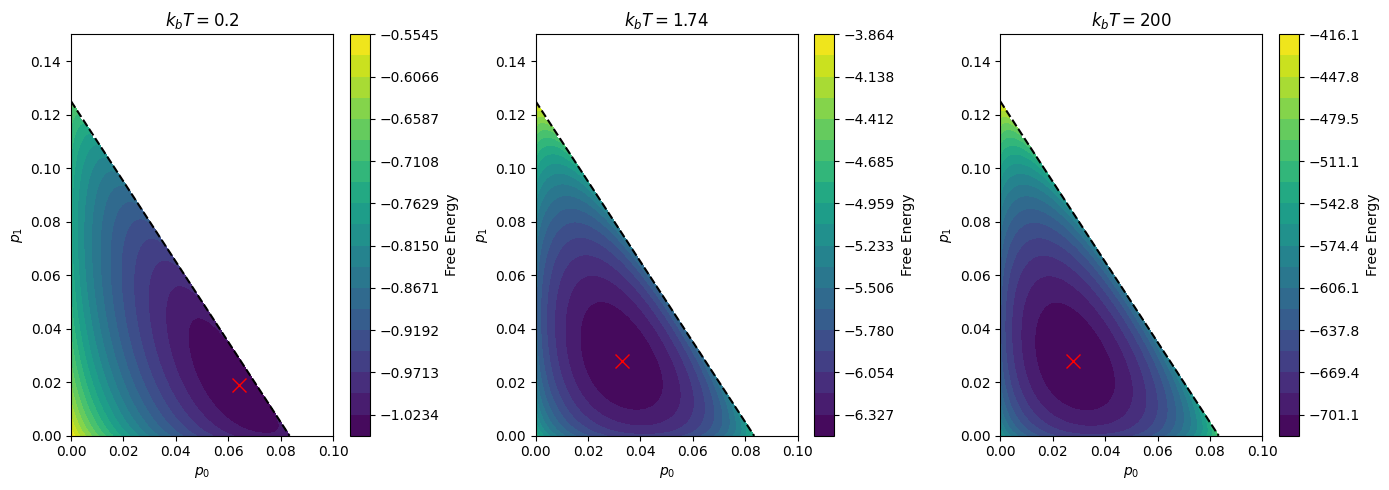

In [7]:
p0s = np.linspace(0, 1/12, 100)
p1s = np.linspace(0, 1/8, 100)
kbTs = np.array([1/5, 1/(2*np.log(4/3)), 200])
fig, axes = plt.subplots(1,3, figsize=(14,5))

energies = np.array([-1/2, -1/4, 0])

for ax, kbT in zip(axes, kbTs):
    fe = FreeEnergySystem(p0s, p1s, kbT)
    fe.plot(ax)

    Z = 12*np.exp(1/2/kbT) + 8*np.exp(1/4/kbT) + 16*np.exp(0*kbT)
    p_boltzmann = 1/Z * np.exp(-energies/kbT)

    opt_p0 = fe.opt_p0
    opt_p1 = fe.opt_p1
    opt_p2 = fe.opt_p2
    p_minimization = [opt_p0, opt_p1, opt_p2]

    print(f'Probabilites [kbT={kbT:.3g}]:')
    for i in range(3):
        print(f'\tExact: {p_boltzmann[i]:.3g},\tOpt: {p_minimization[i]:.3g}')
    print('')
    
fig.tight_layout()

In this exercise I found the minimum on the meshgrid, which is of course a discritized solution. To get a more precise solution, I could have used fmin which can do finite difference with changing step sizes, such that we get machine precision, i.e. should be the exact same as the boltzmann distribution.

$F_T[P]=E[P]-T\cdot S[P]$

<br>

In the limit where $T\rightarrow 0$:

The free energy is dominated by the energy term. Minimizing the energy means increasing the likelyhood of having $E = -1/2$, so $p_0$ should go towards 1 while all other energy state probabilites should go to 0.

Minimizing  $\langle E \rangle =-6p_0-2p_1$ means that $p_0$ should be large.

<br>

In the limit where $T\rightarrow \infty$:

The free energy is dominated by the entropy term. Because of the minus sign we must maximize entropy. The way to maximize entropy is to have the greatest amound of microstates, which we have when each state is equally likely. When we maximize entropy, we know the least possible about our system, so all states must be equally likely.

<!-- To minimize all three log terms, all probabilites must be equally likely. If one probability is just a bit smaller than the others, that shifts the other logarithms upward. -->


# W06B - From two dimensions to one with a potential of mean force

In [1]:
import numpy as np
import matplotlib .pyplot as plt
from matplotlib import cm
from scipy. integrate import quad
from scipy. interpolate import interp1d

In [2]:
class Potential2D:
    xmin = -5
    xmax = 5
    ymin = -5
    ymax = 5

    @classmethod
    def limits(cls):
        return ([cls.xmin, cls.xmax], [cls.ymin, cls.ymax])
    
    x1, y1 = -2.0, 0.0
    x2, y2 = 2.0, 0.0
    alpha = 10.0

    def __init__(self, k1x = 2.0, k1y = 5.0,
                 k2x = 2.0, k2y = 0.5, deltaE = 1):
        self.k1x = k1x
        self.k1y = k1y
        self.k2x = k2x
        self.k2y = k2y
        self.deltaE = deltaE

    def V1(self, x, y):
        return 0.5 * (self.k1x * (x - self.x1)**2
               + self.k1y * (y - self.y1)**2)
    def V2(self, x, y):
        return 0.5 * (self.k2x * (x - self.x2)**2
               + self.k2y * (y - self.y2)**2) + self.deltaE
    def V(self, x, y):
        return -1/self.alpha * np.log(np.exp(-self.alpha*self.V1(x,y)) 
                                      + np.exp(-self.alpha*self.V2(x,y)))
    
    def contour_of_potential_energy(self, ax):
        Nc = 50
        Xs, Ys = np.meshgrid(
            np.linspace(self.xmin, self.xmax, Nc),
            np.linspace(self.ymin, self.ymax, Nc))
        Es = self.V(Xs, Ys)
        levels = np.geomspace(1, 10, 6)
        ax.contourf(Xs, Ys, Es, levels = levels, cmap = cm.YlGnBu)
        ax.contour(Xs, Ys, Es, levels = levels, colors = 'k')
        ax.set_title('V(x,y)')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
                        
    def plot1d(self, ax):
        xs = np.linspace(self.xmin, self.xmax, 1000)
        zs = self.V(xs, 0)
        ax.plot(xs, zs)
        ax.set_title('V(x,0)')
        ax.set_ylim([-0.5, 13.5])

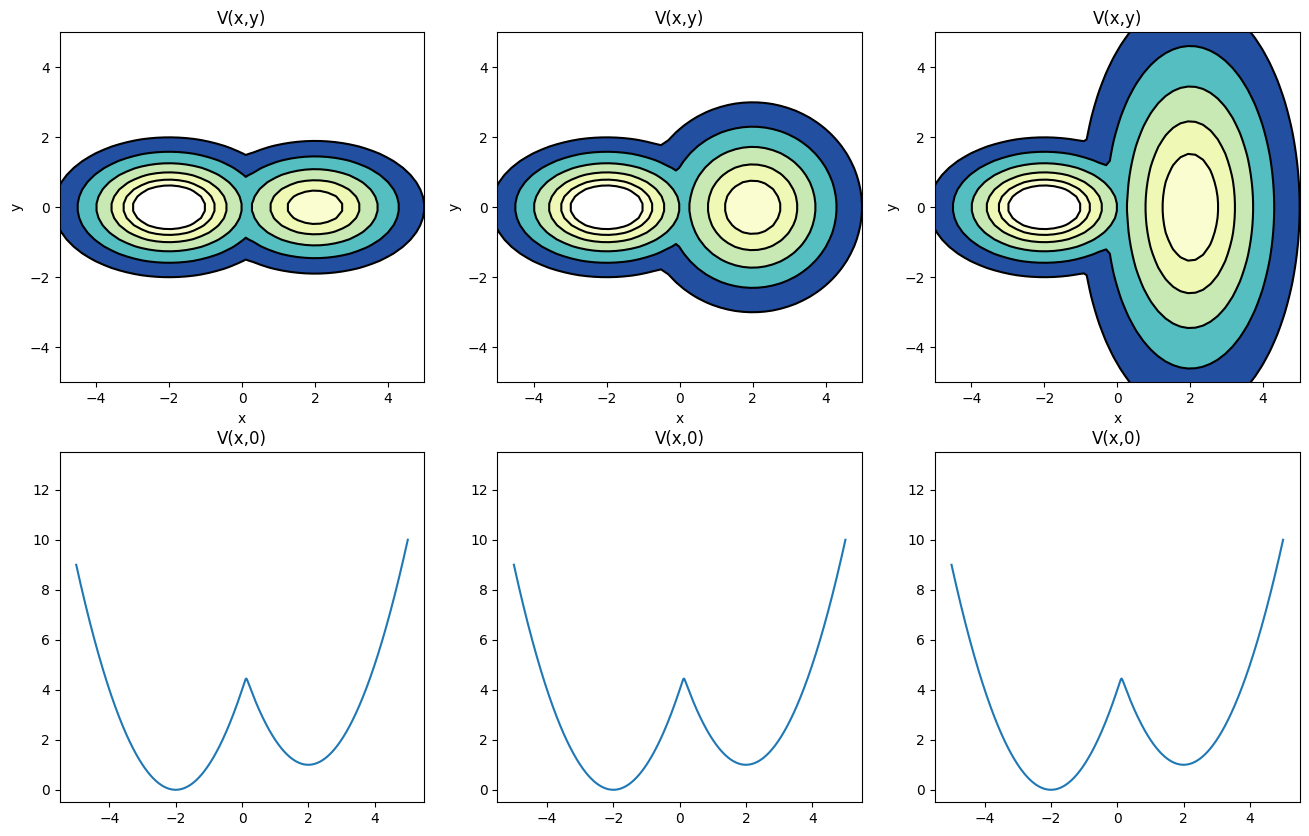

In [3]:
fig, axes = plt.subplots(2,3,figsize=(16,10))

for i, k2y in enumerate([5,2,0.5]):
    pot = Potential2D(k2y=k2y)
    pot.contour_of_potential_energy(axes[0,i])
    pot.plot1d(axes[1,i])

In [4]:
class Particle:
    def __init__(self, potential_2d, P0=[0., 0.]):
        self.potential_2d = potential_2d
        self.pos = np.array(P0)
        self.velocities = np.zeros(self.pos.shape)

    def set_positions(self, pos):
        self.pos = pos

    def get_positions(self):
        return self.pos.copy()
    
    @property
    def potential_energy(self):
        return self.potential_2d.V(*self.pos)


class Simulation(Particle):
    def __init__(self, *args, kT=2, Nsample_size=1000, **kwargs):
        super().__init__ (*args, **kwargs)
        self._sample = None
        self.Nsample_size = Nsample_size
        self._kT = kT

    @property
    def kT(self):
        return self._kT

    @kT.setter
    def kT(self, new_kT):
        print('...changing kT')
        if self._kT != new_kT:
            self._sample = None
            self._kT = new_kT

    @property
    def sample(self):
        if self._sample is None:
            self.setup_sample()
        return self._sample
    
    def plot_sample_raster(self, ax, bins=50):
        x = self.sample[:, 0]
        y = self.sample[:, 1]
        limits = self.potential_2d.limits()
        heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins, range=limits)
        extent = [xedges[0], xedges[-1], yedges[0], yedges[ -1]]
        ax.imshow(heatmap.T, extent=extent, origin='lower', aspect='auto', cmap='hot')
        ax.set_title('P(x,y)')
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    # MY CODE
    def plot1D_sample(self, ax, bins=50, bottom=0):
        x = self.sample[:, 0]
        # y = self.sample[:, 1]
        limits = self.potential_2d.limits()
        self.potential_2d.plot1d(ax)

        counts, bin_edges = np.histogram(x, bins=bins, range=limits[0])
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_width = bin_edges[1] - bin_edges[0]
        P = counts/np.sum(counts)/bin_width
        # P_scaled = P * 20
        ax.bar(bin_centers, P*20, width=bin_width, facecolor='C0', alpha=0.25, bottom=bottom)
        ax.bar(bin_centers, P*20, width=bin_width, facecolor='None', edgecolor='k', bottom=bottom)
        ax.set_title(r'$V(x,y=0),\, P(x),\, kT=$'+f'{self.kT}')

        P_left = sum(P[bin_centers < 0]) * bin_width
        P_right = sum(P[bin_centers > 0]) * bin_width
        ax.text(-2, 12, r'$P_{left}=$'+f'{P_left:.2f}', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.5,edgecolor='none'), size=12)
        ax.text(2, 12, r'$P_{right}=$'+f'{P_right:.2f}', ha='center', va='center',
                                bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.5,edgecolor='none'), size=12)

                        
class MonteCarlo(Simulation):
    def setup_sample(self):
        ((xmin, xmax), (ymin, ymax)) = self.potential_2d.limits()
        Ps = []
        P = self.pos
        for _ in range(self.Nsample_size):
            Ps.append(P)
            x_new = xmin + (xmax - xmin) * np.random.rand()
            y_new = ymin + (ymax - ymin) * np.random.rand()
            P_new = [x_new, y_new]
            de = (self.potential_2d.V(*P_new)
                  - self.potential_2d.V(*P))

            # MY CODE
            acceptance_probability = min(1, np.exp(-de / self.kT))
            if np.random.rand() < acceptance_probability:
                P = P_new
                # self.set_positions(P_new)

        self._sample = np.array(Ps)
        print('Sample size:', len(self.sample))

Sample size: 100000
Sample size: 100000
Sample size: 100000


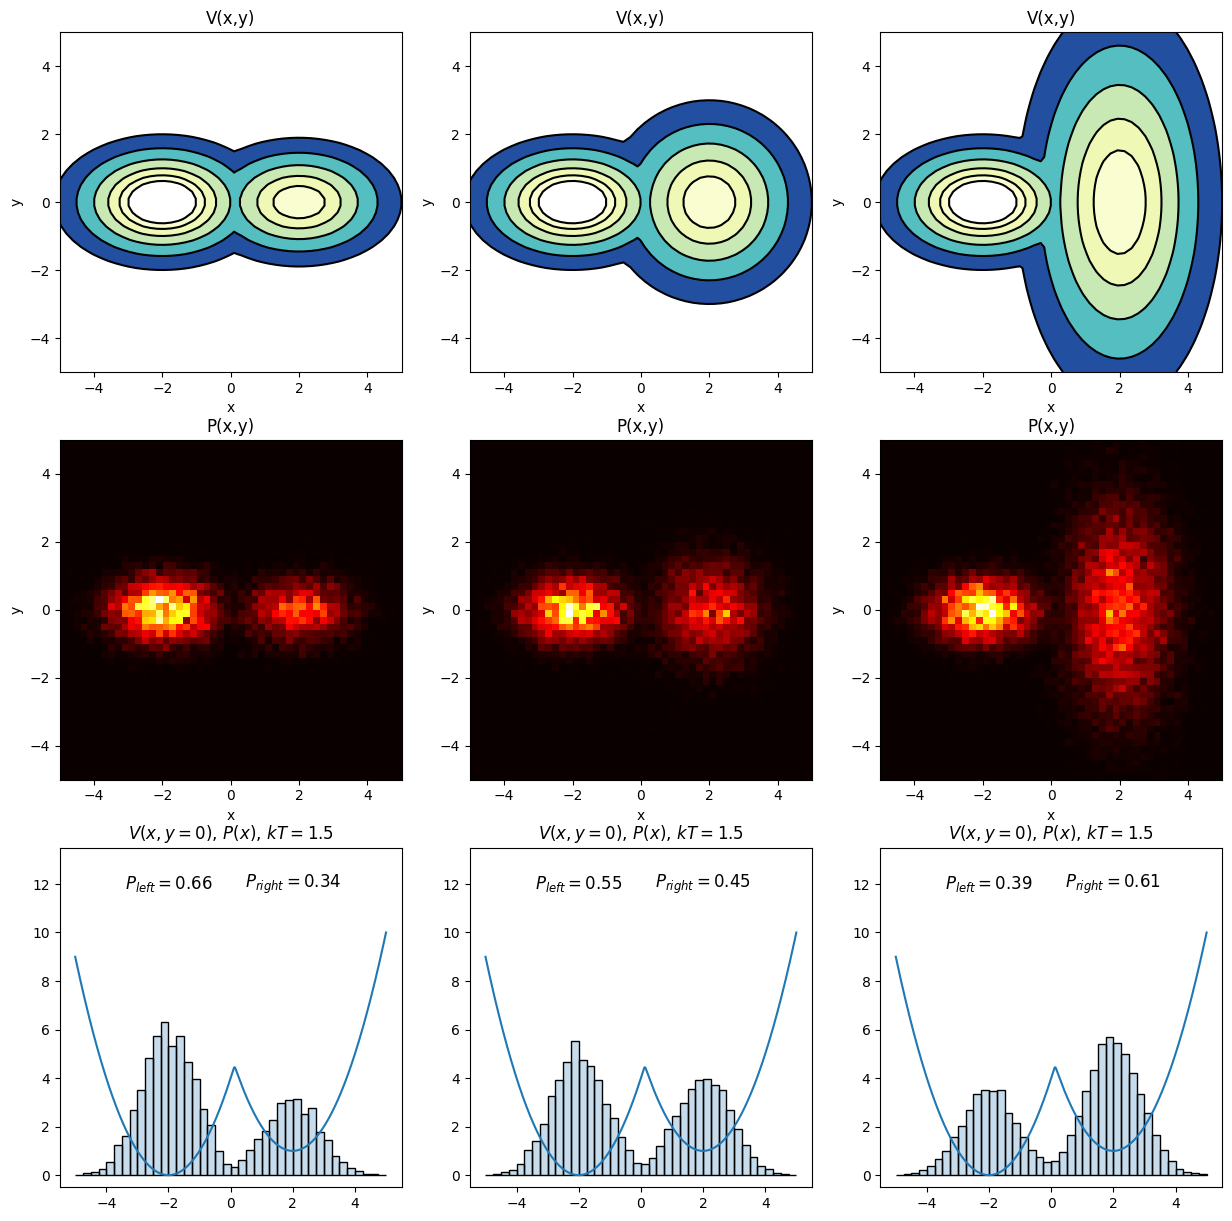

In [5]:
fig, axes = plt.subplots(3,3,figsize=(15,15))

for i, k2y in enumerate([5,2,0.5]):
    pot = Potential2D(k2y=k2y)
    mc_system = MonteCarlo(pot, kT=1.5, Nsample_size=100_000)
    pot.contour_of_potential_energy(axes[0,i])
    mc_system.plot_sample_raster(axes[1,i])
    mc_system.plot1D_sample(axes[2,i], bins=40)
    


There is a larger phase-space when we change ky2, such that the particle has more possible positions for the same x-values. The first figure (left) makes sense; there are more states in the lower potential. As we move to lower ky2 (right), it doesn't make as much sense in 1D; there are higher probability of being in the higher potential.

### Task 3

Sample size: 50000
Sample size: 50000
Sample size: 50000
Sample size: 50000
Sample size: 50000
Sample size: 50000


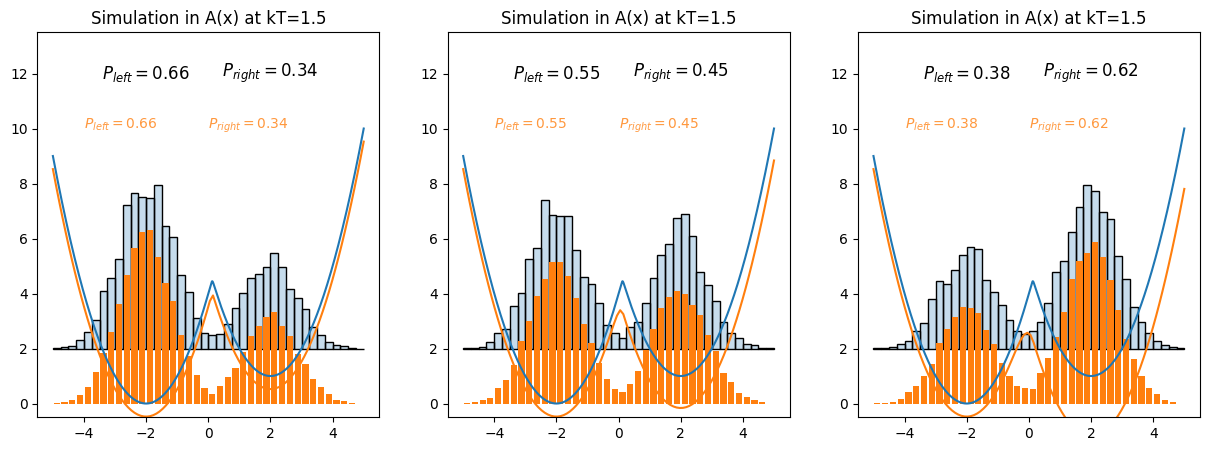

In [6]:
from week06 import MonteCarlo1D


fig, axes = plt.subplots(1,3,figsize=(15,5))

kT = 1.5
for i, k2y in enumerate([5,2,0.5]):
    pot = Potential2D(deltaE=1, k2y=k2y)
    mc_system = MonteCarlo(pot, kT=kT, Nsample_size=50_000)
    mc_system.plot1D_sample(axes[i], bins=40, bottom=2)

    ylimits = pot.limits()[1]
    a = lambda x: -kT*np.log(quad(lambda y : np.exp(-pot.V(x,y)/kT), ylimits[0], ylimits[1])[0])

    xs = np.linspace(*pot.limits()[0], 100)
    avals = [a(x) for x in xs]
    a_approx = interp1d(xs, avals)

    monte_carlo_for_A = MonteCarlo1D(
        a_approx, Nsim=50000,
        transition_method='uniform', kT=kT)
    monte_carlo_for_A.plot(axes[i], color='C1', alpha=1)

We see that determining the mean force potential A(x) and doing 1 dimensional Metropolis Monte Carlo leads to a very similar probability distribution. However, in contrary to the earlier task, the distribution now makes more sense compared with its potential. The lower potential has higher probability.

### Task 4 - changing kT

Sample size: 100000
Sample size: 100000
Sample size: 100000


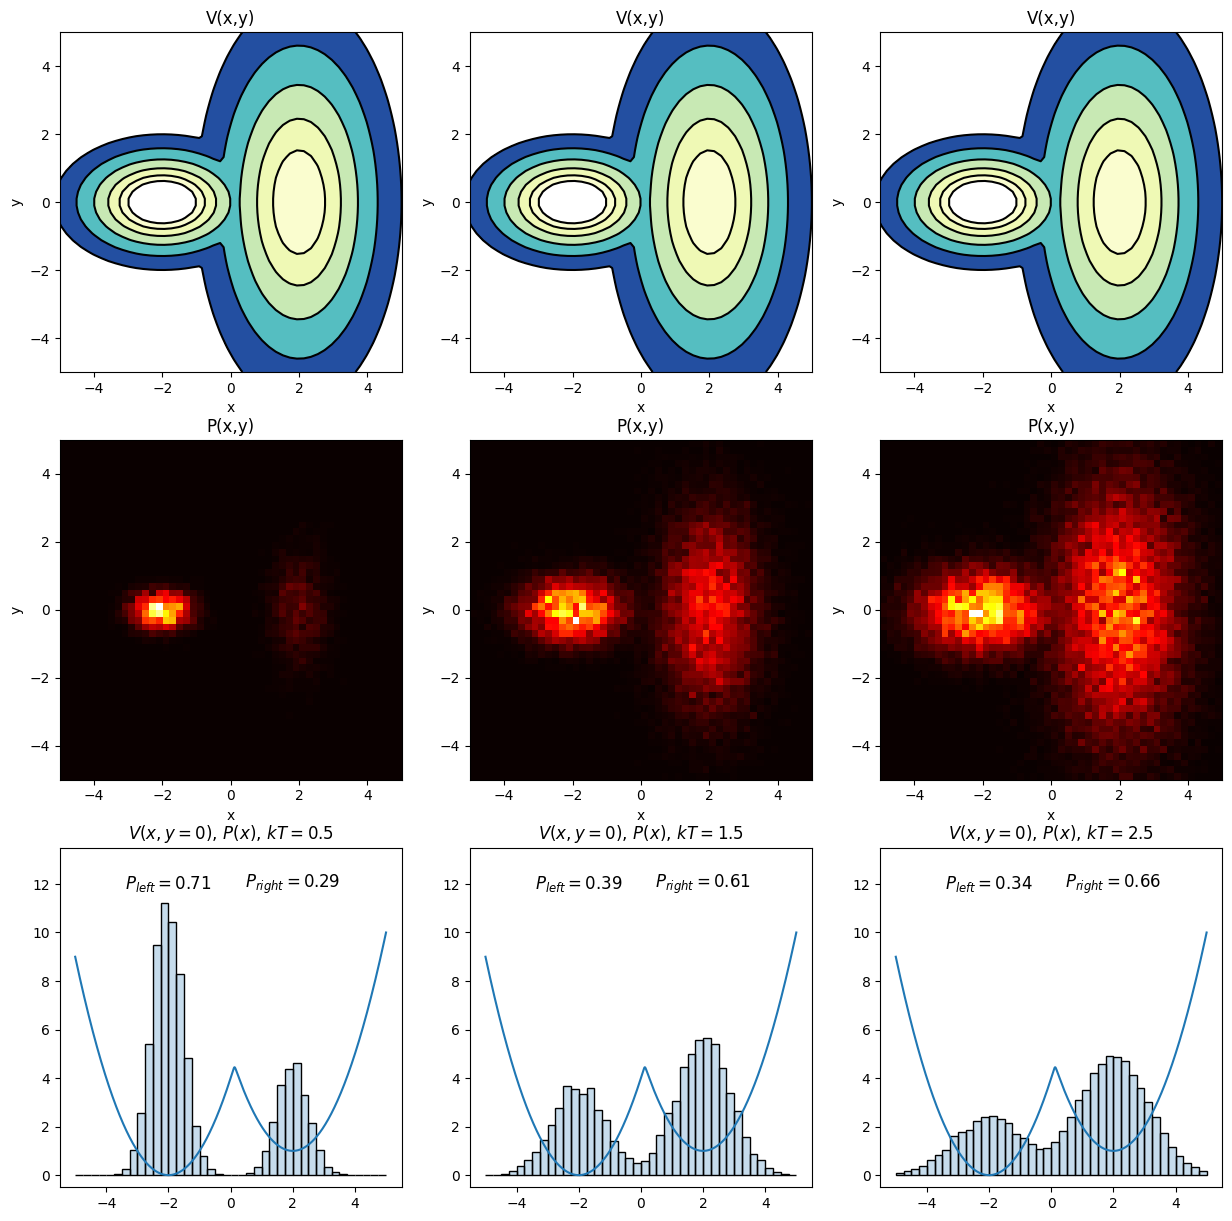

In [7]:
fig, axes = plt.subplots(3,3,figsize=(15,15))

k2y = 0.5
for i, kT in enumerate([0.5, 1.5, 2.5]):
    pot = Potential2D(k2y=k2y)
    mc_system = MonteCarlo(pot, kT=kT, Nsample_size=100_000)
    pot.contour_of_potential_energy(axes[0,i])
    mc_system.plot_sample_raster(axes[1,i])
    mc_system.plot1D_sample(axes[2,i], bins=40)
    


Now as the temperature increases, it becomes increasingly likely for the particle to jump from the low potential to the high potential. Since there are more possible y-values for the same x-values here, the probability of being in the higher potential is largest.

### Task 5

Sample size: 50000
Sample size: 50000
Sample size: 50000
Sample size: 50000
Sample size: 50000
Sample size: 50000


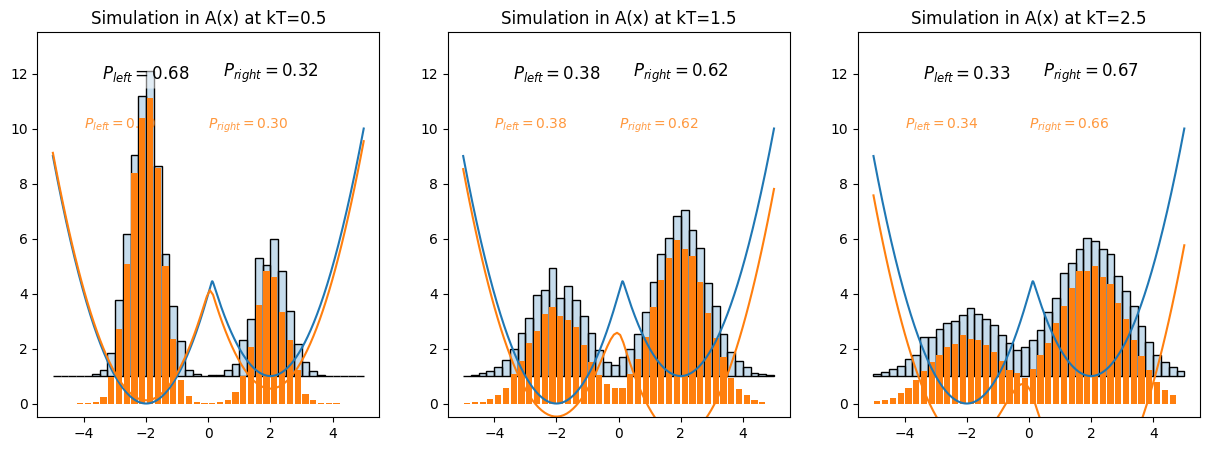

In [13]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

k2y = 0.5
for i, kT in enumerate([0.5, 1.5, 2.5]):
    pot = Potential2D(deltaE=1, k2y=k2y)
    mc_system = MonteCarlo(pot, kT=kT, Nsample_size=50_000)
    mc_system.plot1D_sample(axes[i], bins=40, bottom=1)

    ylimits = pot.limits()[1]
    a = lambda x: -kT*np.log(quad(lambda y : np.exp(-pot.V(x,y)/kT), ylimits[0], ylimits[1])[0])

    xs = np.linspace(*pot.limits()[0], 100)
    avals = [a(x) for x in xs]
    a_approx = interp1d(xs, avals)

    monte_carlo_for_A = MonteCarlo1D(
        a_approx, Nsim=50000,
        transition_method='uniform', kT=kT)
    monte_carlo_for_A.plot(axes[i], color='C1', alpha=1)

We can verify that one-dimensional sampling reproduces the corresponding marginal distributions and populations.

Notes from lecture:

We know that $P(x)\propto \exp(-A(x)/k_bT)$. There must exist a function A(x) that describes the probability distribtution.

Thus: $P(x,y)dy\propto \exp(-A(x)/k_bT)$

and $\ln\int P(x,y)dy = -A(x)/k_bT + const$

Such that:

$A(x) = -k_bT\ln\int P(x,y)dy + const = -k_bT\ln\int\exp(-V(x,y)/k_bT)dy+const$

And now we sample x from our Metropolis Monte Carlo which we know to follow boltzmann statistics. We BUILD the Metropolis Monte Carlo in that way, saying that $A(x'|x) = min(1, \exp(-\delta E/k_bT))$, such that "particles does not float away to wild energies".

<br>

The "area" we get in the 'raster' plot is also the area we see in the probability distribtuion. 

<br>

In this exercise we needed to know $P(x,y)$. In the next exercise we only know that it is described by an harmonic oscillator.

# W06C A two-state harmonic-oscillator model

C:\Users\emilk\AppData\Local\Temp\ipykernel_36420\2127137346.py:30: RuntimeWarning: divide by zero encountered in log
  return -1/self.alpha * np.log(np.exp(-self.alpha*self.V1(x,y))


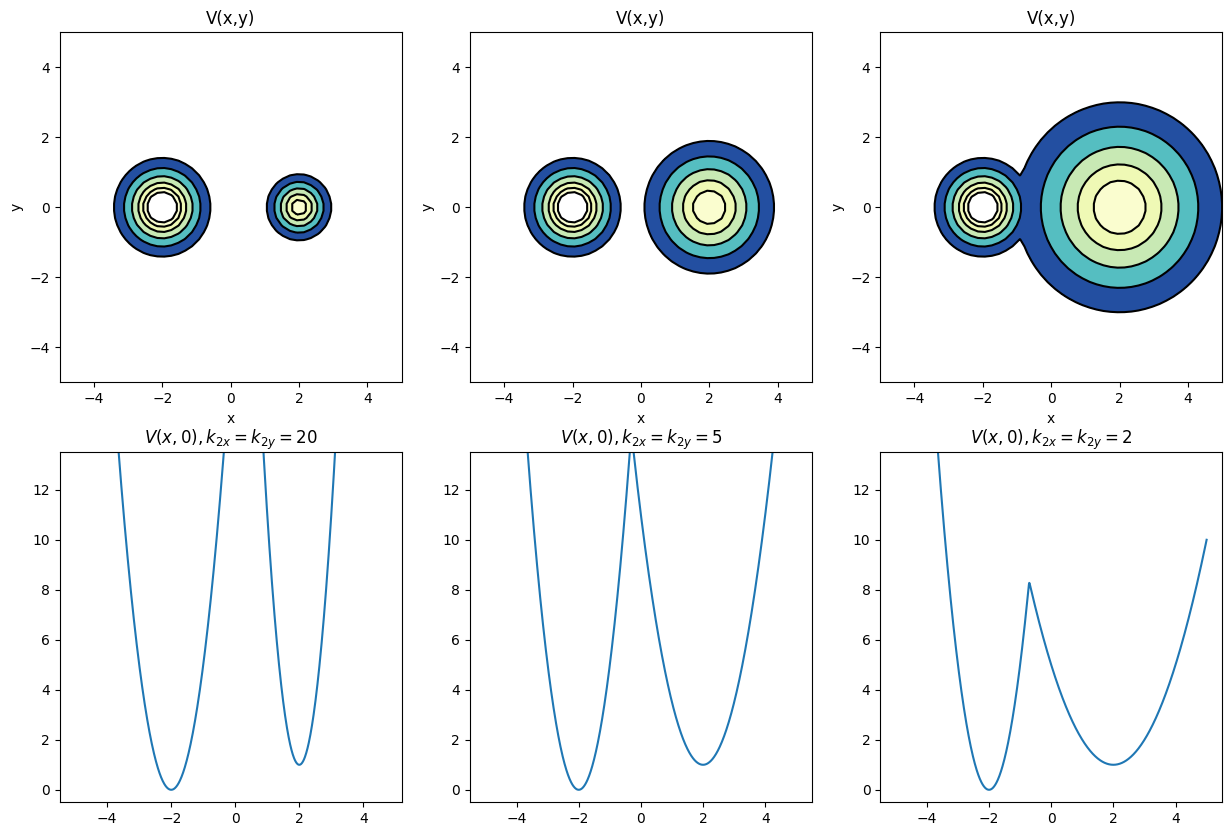

In [16]:
fig, axes = plt.subplots(2,3,figsize=(15,10))

kT = 1.5
for i, k2 in enumerate([20, 5, 2]):
    two_state_pot = Potential2D(k1x=10, k1y=10, k2x=k2, k2y=k2)
    two_state_pot.contour_of_potential_energy(axes[0, i])
    two_state_pot.plot1d(axes[1,i])
    axes[1,i].set_title(r'$V(x,0), k_{2x}=k_{2y}=$'+f'{k2}')


Based on the relative depths and widths of the wells: With k2=20 I would expect highest equilibrium population in the left well. For k2=5, I expect the populations would be roughly equally distributed at equilibrium, with the higher well also being wider. For k2=2, I would expect most of the equilibrium population in the right well.

### Task 2 - Solve the problem in full 2D

C:\Users\emilk\AppData\Local\Temp\ipykernel_36420\2127137346.py:30: RuntimeWarning: divide by zero encountered in log
  return -1/self.alpha * np.log(np.exp(-self.alpha*self.V1(x,y))


Sample size: 100000
Sample size: 100000
Sample size: 100000


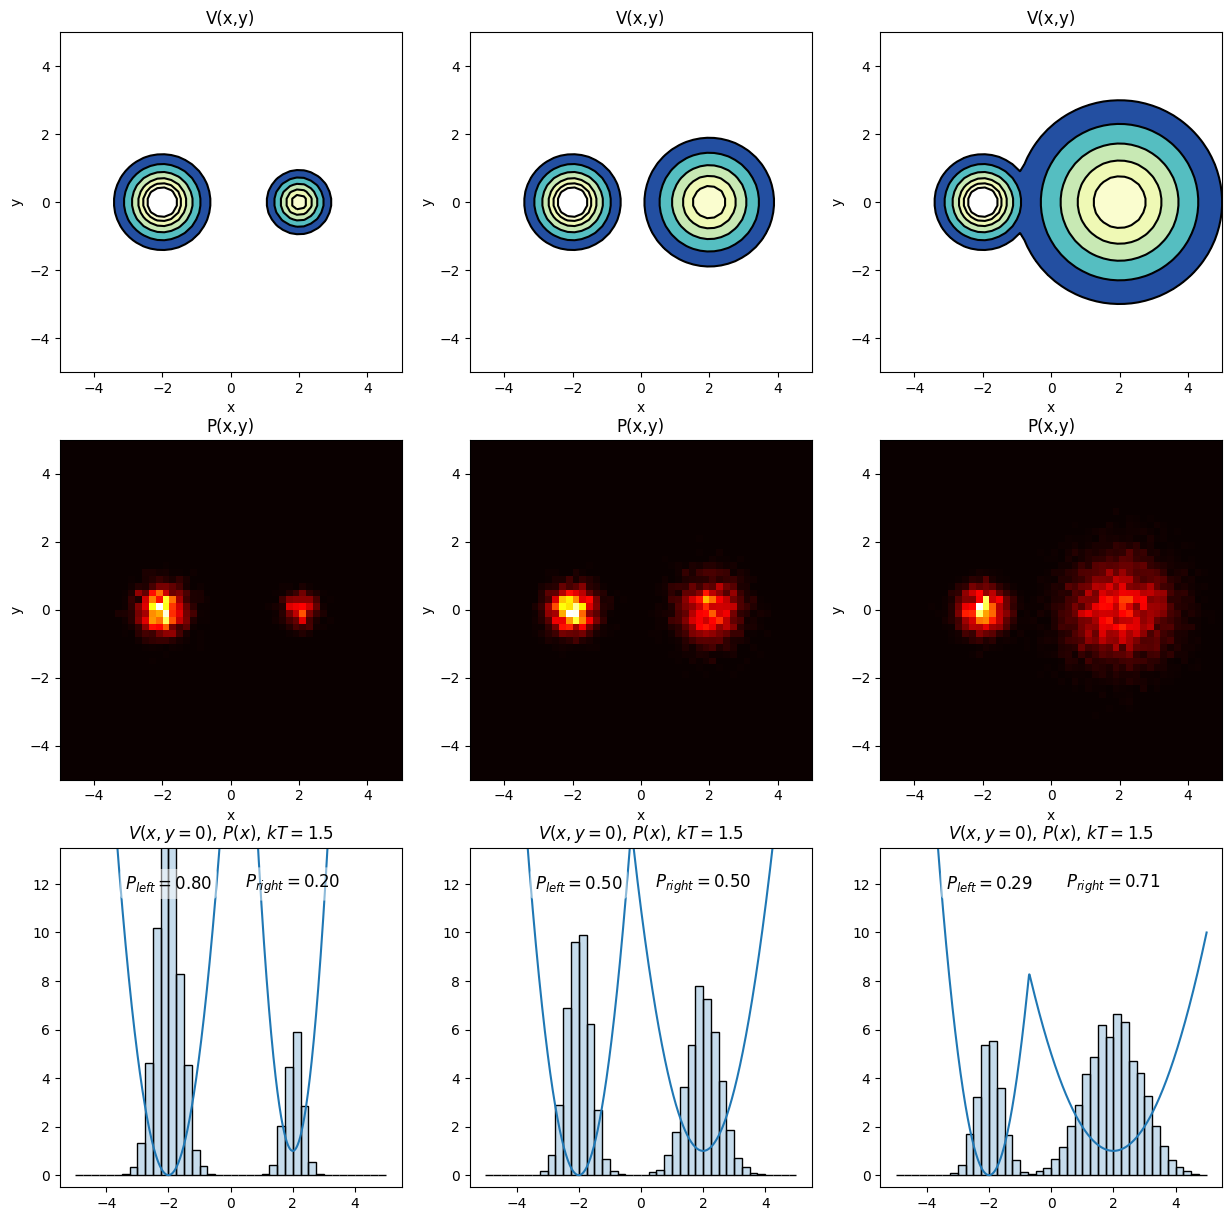

In [17]:
fig, axes = plt.subplots(3,3,figsize=(15,15))

kT = 1.5
for i, k2 in enumerate([20, 5, 2]):
    two_state_pot = Potential2D(k1x=10, k1y=10, k2x=k2, k2y=k2)
    mc_two_state = MonteCarlo(two_state_pot, kT=kT, Nsample_size=100_000)
    two_state_pot.contour_of_potential_energy(axes[0,i])
    mc_two_state.plot_sample_raster(axes[1,i])
    mc_two_state.plot1D_sample(axes[2,i], bins=40)
    


It appears my intuition was correct. Though the right well is higher, as the width increases so does the population. The phase-space increases, so there are more possible positions for the particle to be in.

### Task 3 - solve the problem in 1D

$V(x,0)=- \ln(1/\alpha)\exp(-\alpha$

C:\Users\emilk\AppData\Local\Temp\ipykernel_36420\2127137346.py:30: RuntimeWarning: divide by zero encountered in log
  return -1/self.alpha * np.log(np.exp(-self.alpha*self.V1(x,y))


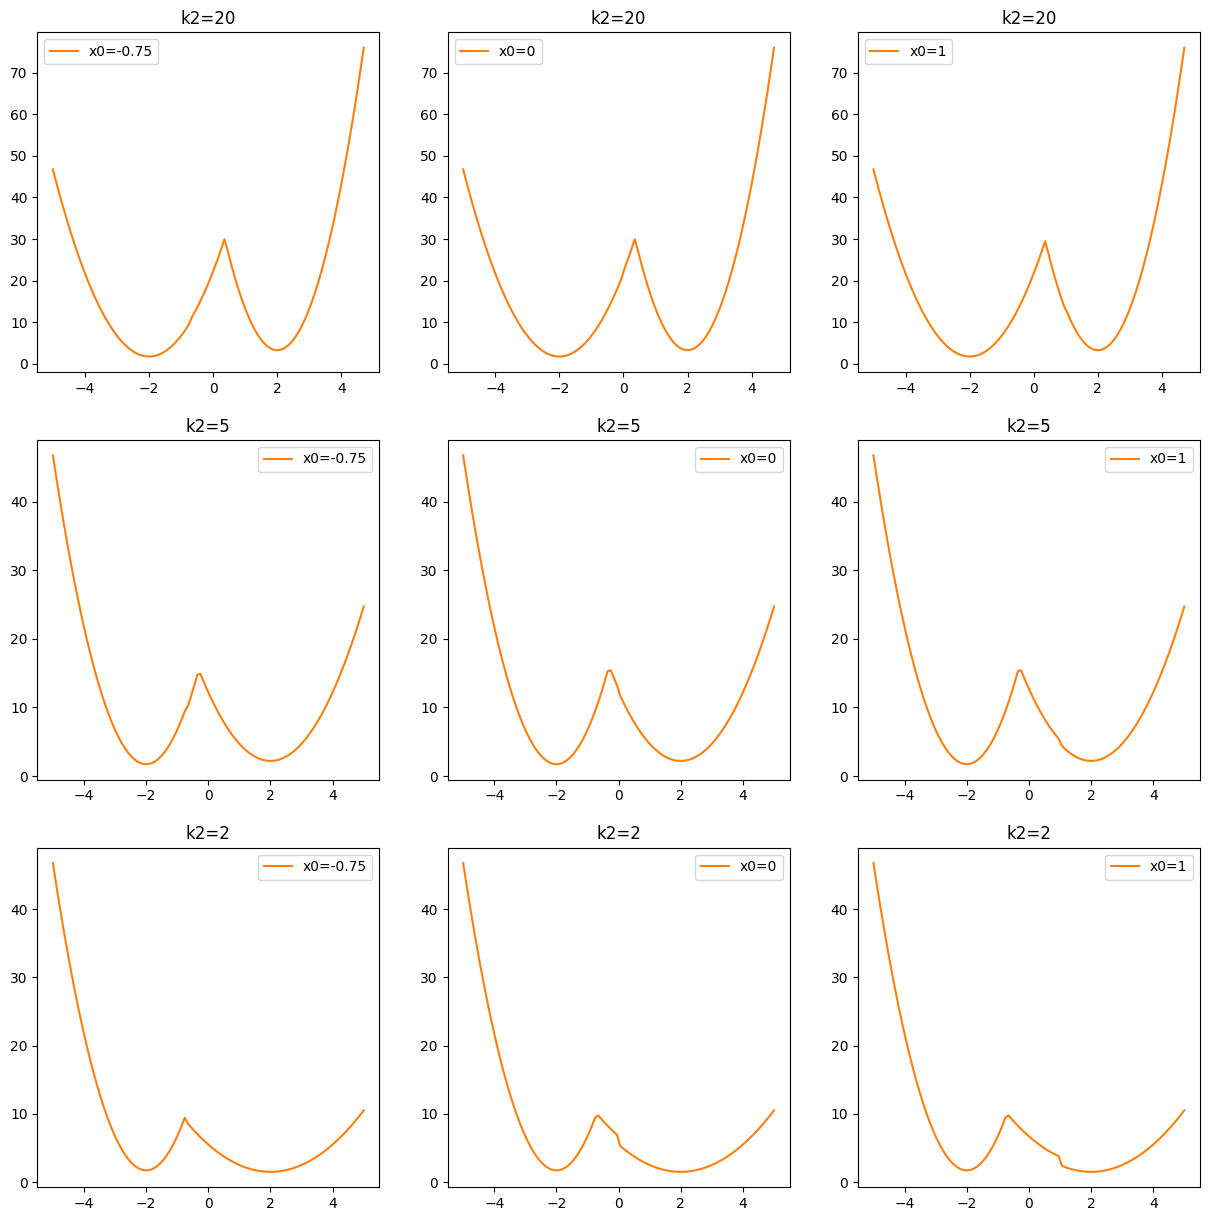

In [31]:
fig, axes = plt.subplots(3,3,figsize=(15,15))


kT = 1.5
k1 = 10
for i, x0 in enumerate([-0.75,0,1]):
    for j, k2 in enumerate([20, 5, 2]):
        two_state_pot = Potential2D(k1x=k1, k1y=k1, k2x=k2, k2y=k2)
        a = lambda x: two_state_pot.V(x, 0) + 1/2*kT*np.log(k1) if x < x0 \
                    else two_state_pot.V(x, 0) + 1/2*kT*np.log(k2)

        xs = np.linspace(*two_state_pot.limits()[0], 100)
        avals = [a(x) for x in xs]
        a_approx = interp1d(xs, avals)

        axes[j,i].plot(xs, avals, c='C1', label=f'x0={x0}')
        axes[j,i].legend()
        axes[j,i].set_title(f'k2={k2}')



C:\Users\emilk\AppData\Local\Temp\ipykernel_36420\2127137346.py:30: RuntimeWarning: divide by zero encountered in log
  return -1/self.alpha * np.log(np.exp(-self.alpha*self.V1(x,y))


Sample size: 50000
Sample size: 50000
Sample size: 50000
Sample size: 50000
Sample size: 50000
Sample size: 50000


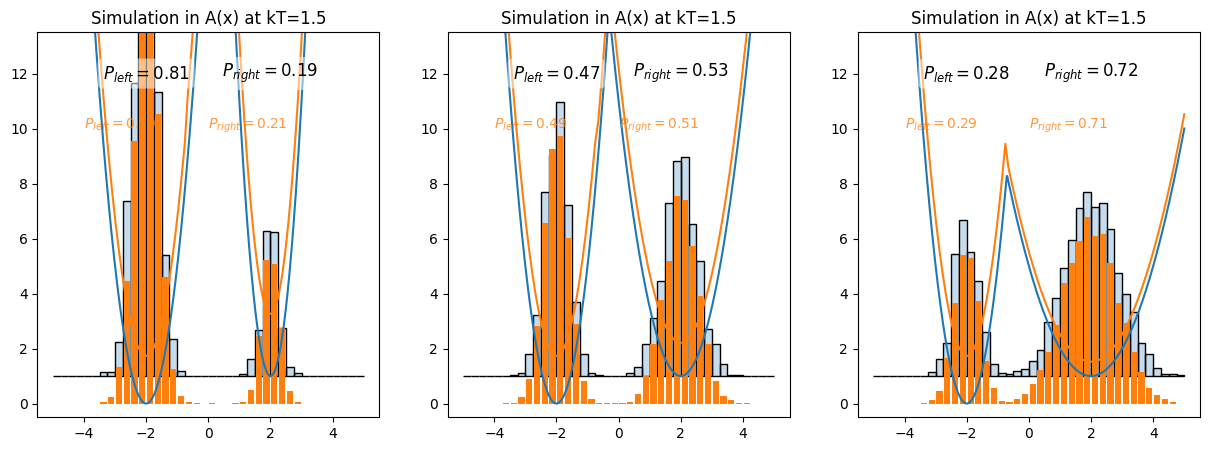

In [33]:
from week06 import MonteCarlo1D

fig, axes = plt.subplots(1,3,figsize=(15,5))

x0 = -0.75
kT = 1.5
for i, k2 in enumerate([20, 5, 2]):
    two_state_pot = Potential2D(k1x=k1, k1y=k1, k2x=k2, k2y=k2)
    mc_system = MonteCarlo(two_state_pot, kT=kT, Nsample_size=50_000)
    mc_system.plot1D_sample(axes[i], bins=40, bottom=1)

    a = lambda x: two_state_pot.V(x, 0) + 1/2*kT*np.log(k1) if x < x0 \
                else two_state_pot.V(x, 0) + 1/2*kT*np.log(k2)

    xs = np.linspace(*two_state_pot.limits()[0], 100)
    avals = [a(x) for x in xs]
    a_approx = interp1d(xs, avals)

    monte_carlo_for_A = MonteCarlo1D(
        a_approx, Nsim=50000,
        transition_method='uniform', kT=kT)
    monte_carlo_for_A.plot(axes[i], color='C1', alpha=1)

### Task 4 - Solve in zero dimensions with Free Energy

In [41]:
x1=-2
x2=2
k1 = 10
for k2 in [20, 5, 2]:
    print(f'{k2=}')
    free_energy_pot = Potential2D(k1x=k1, k1y=k1, k2x=k2, k2y=k2)  #x1=-2, x2=2
    free_energy_1 = free_energy_pot.V(x1, 0) + 1/2*kT*np.log(k1*k1)
    free_energy_2 = free_energy_pot.V(x2, 0) + 1/2*kT*np.log(k2*k2)

    # Very explicit, could've been written in one exponential with deltaF
    Z = np.exp(-free_energy_1/kT) + np.exp(-free_energy_2/kT)
    p1 = 1/Z * np.exp(-free_energy_1/kT)
    p2 = 1/Z * np.exp(-free_energy_2/kT)
    print(f'{p1=:.2f}\n{p2=:.2f}\n')
    
    

k2=20
p1=0.80
p2=0.20

k2=5
p1=0.49
p2=0.51

k2=2
p1=0.28
p2=0.72



A narrow but deep well has low energy and offers preferable microstates in the Boltzmann distribution. However, the number of microstates is much greater in a wider well, although at a higher potential, so when the second well is wide enough, it has the highest equilibrium population: so many more microstates (larger phase-space)